<a href="https://colab.research.google.com/github/ishaanabd17-eng/ML_project/blob/main/Customer_Churn_Elastic_Net_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ============================================================
# CUSTOMER CHURN PREDICTION
# ELASTIC NET REGULARIZED LOGISTIC REGRESSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
import io

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

Saving Telco-Customer-Churn (1) (1).csv to Telco-Customer-Churn (1) (1).csv
Dataset loaded successfully!
File: Telco-Customer-Churn (1) (1).csv
Shape: (7043, 21)


In [3]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# Remove customer ID because it is only an identifier
df = df.drop(columns=["customerID"])

print("Shape after removing customerID:", df.shape)

Missing TotalCharges: 11
Shape after removing customerID: (7043, 20)


In [4]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [5]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining churn distribution:")
print(y_train.value_counts())

print("\nTesting churn distribution:")
print(y_test.value_counts())

Training samples: 5634
Testing samples : 1409

Training churn distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing churn distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [8]:
elastic_net_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

print("Elastic Net Logistic Regression created successfully.")

Elastic Net Logistic Regression created successfully.


In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]
}

grid_search = GridSearchCV(
    estimator=elastic_net_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Starting hyperparameter tuning...")

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")
print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

Starting hyperparameter tuning...
Hyperparameter tuning completed!

Best Parameters:
{'classifier__C': 100, 'classifier__l1_ratio': 0.25}

Best Cross-Validation ROC-AUC:
0.8459


In [11]:
final_model = grid_search.best_estimator_

print("Final Elastic Net model selected.")
print("Best parameters:", grid_search.best_params_)

Final Elastic Net model selected.
Best parameters: {'classifier__C': 100, 'classifier__l1_ratio': 0.25}


In [12]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of test predictions:", len(y_pred))

Predictions generated successfully.
Number of test predictions: 1409


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(4)

display(results)

,Metric,Score
0,Accuracy,0.8006
1,Precision,0.6467
2,Recall,0.5481
3,F1-Score,0.5933
4,ROC-AUC,0.8407


In [14]:
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



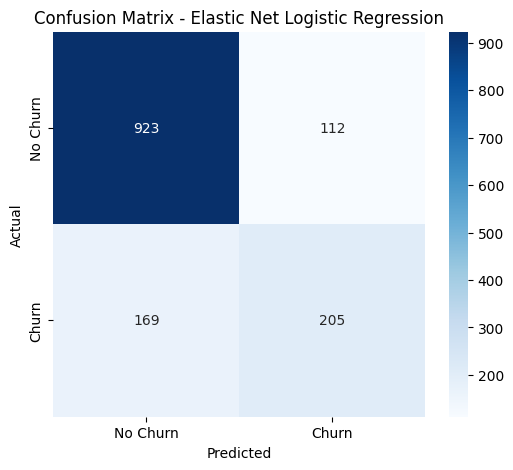

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Elastic Net Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 700x500 with 0 Axes>

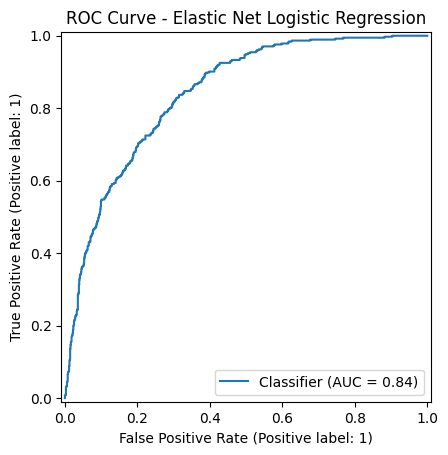

In [16]:
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Elastic Net Logistic Regression")
plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# BENCHMARK MODELS
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

benchmark_results = []

for name, classifier in models.items():

    print(f"Training {name}...")

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    benchmark_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

benchmark_df = pd.DataFrame(benchmark_results)

# Add our already-trained Elastic Net results
elastic_net_row = pd.DataFrame([{
    "Model": "Elastic Net Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}])

benchmark_df = pd.concat(
    [elastic_net_row, benchmark_df],
    ignore_index=True
)

benchmark_df.iloc[:, 1:] = benchmark_df.iloc[:, 1:].round(4)

print("\nMODEL COMPARISON")
print("=" * 70)

display(benchmark_df)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Elastic Net Logistic Regression,0.8006,0.6467,0.5481,0.5933,0.8407
1,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
2,Decision Tree,0.7289,0.4896,0.5053,0.4974,0.6573
3,Random Forest,0.7757,0.6000,0.4652,0.5241,0.8186


In [18]:
# ============================================================
# ELASTIC NET FEATURE COEFFICIENTS
# ============================================================

# Get feature names after preprocessing
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Elastic Net coefficients
coefficients = final_model.named_steps[
    "classifier"
].coef_[0]

# Create feature coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient
coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

print("TOP FEATURES ASSOCIATED WITH HIGHER CHURN")
print("=" * 60)
display(coef_df.head(10))

print("\nTOP FEATURES ASSOCIATED WITH LOWER CHURN")
print("=" * 60)
display(coef_df.tail(10))

TOP FEATURES ASSOCIATED WITH HIGHER CHURN


,Feature,Coefficient
16,cat__InternetService_Fiber optic,1.529357
35,cat__StreamingMovies_Yes,0.629750
32,cat__StreamingTV_Yes,0.628646
3,num__TotalCharges,0.568025
36,cat__Contract_Month-to-month,0.535559
14,cat__MultipleLines_Yes,0.414157
26,cat__DeviceProtection_Yes,0.295337
23,cat__OnlineBackup_Yes,0.220549
43,cat__PaymentMethod_Electronic check,0.165756
11,cat__PhoneService_Yes,0.117719



TOP FEATURES ASSOCIATED WITH LOWER CHURN


,Feature,Coefficient
19,cat__OnlineSecurity_No internet service,-0.696551
17,cat__InternetService_No,-0.696551
34,cat__StreamingMovies_No internet service,-0.696551
31,cat__StreamingTV_No internet service,-0.696551
22,cat__OnlineBackup_No internet service,-0.696551
25,cat__DeviceProtection_No internet service,-0.696551
38,cat__Contract_Two year,-0.844813
1,num__tenure,-1.290848
15,cat__InternetService_DSL,-1.305376
2,num__MonthlyCharges,-2.460897


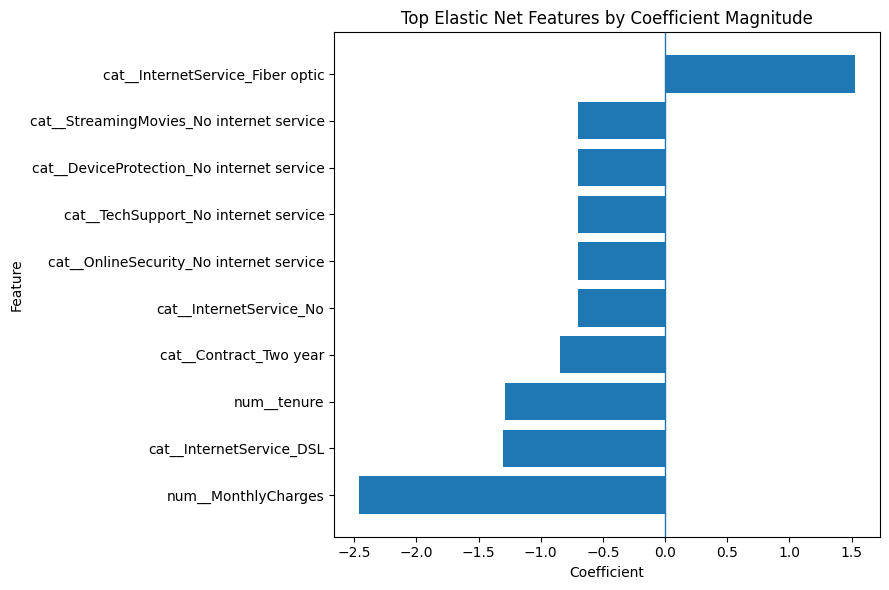

In [19]:
# Top 10 features by absolute coefficient
top_features = (
    coef_df
    .assign(AbsCoefficient=lambda x: x["Coefficient"].abs())
    .sort_values("AbsCoefficient", ascending=False)
    .head(10)
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Top Elastic Net Features by Coefficient Magnitude")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# EXAMPLE CUSTOMER PREDICTION
# ============================================================

sample_customer = X_test.iloc[[0]]

actual = y_test.iloc[0]
prediction = final_model.predict(sample_customer)[0]
probability = final_model.predict_proba(sample_customer)[0, 1]

print("EXAMPLE CUSTOMER PREDICTION")
print("=" * 60)

print("Actual Churn :", "Yes" if actual == 1 else "No")
print("Predicted Churn:", "Yes" if prediction == 1 else "No")
print("Churn Probability:", round(probability * 100, 2), "%")

EXAMPLE CUSTOMER PREDICTION
Actual Churn : No
Predicted Churn: No
Churn Probability: 4.8 %


In [21]:
import joblib

joblib.dump(
    final_model,
    "elastic_net_churn_model.pkl"
)

print("Model saved successfully as:")
print("elastic_net_churn_model.pkl")

Model saved successfully as:
elastic_net_churn_model.pkl
